# XGBoost 기반 전기차 충전소 최적화 예측모델과 공간 클러스터링 분석
# XGBoost-Based Optimization and Spatial Clustering of EV Charging Infrastructure

한글 폰트

In [24]:
!pip install statsmodels
!pip install xgboost
!pip install graphviz
!pip install pydotplus
!pip install pandas geopandas folium
!pip install folium


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

데이터프레임 정의

In [48]:
import pandas as pd

# Seoul District EV Infrastructure + Average Income DataFrame
df = pd.DataFrame({
    'district': [
        'Gangnam-gu', 'Gangdong-gu', 'Gangbuk-gu', 'Gangseo-gu', 'Gwanak-gu',
        'Gwangjin-gu', 'Guro-gu', 'Geumcheon-gu', 'Nowon-gu', 'Dobong-gu',
        'Dongdaemun-gu', 'Dongjak-gu', 'Mapo-gu', 'Seodaemun-gu', 'Seocho-gu',
        'Seongdong-gu', 'Seongbuk-gu', 'Songpa-gu', 'Yangcheon-gu', 'Yeongdeungpo-gu',
        'Yongsan-gu', 'Eunpyeong-gu', 'Jongno-gu', 'Jung-gu', 'Jungnang-gu'
    ],
    'num_ev': [
        14117, 4147, 1468, 4390, 2253,
        1751, 5690, 1696, 2842, 1991,
        2766, 2639, 3286, 2108, 8874,
        2765, 2736, 7591, 3291, 5819,
        2932, 2328, 1389, 2447, 2501
    ],
    'population': [
        563189, 500002, 288797, 560094, 497213,
        348660, 410727, 238431, 495111, 305391,
        342492, 389561, 366111, 309237, 418086,
        291900, 438329, 672439, 458189, 371319,
        228399, 482040, 146790, 125765, 368112
    ],
    'parking_spaces': [
        436740, 212658, 96070, 322335, 147527,
        138776, 190838, 160301, 347011, 120311,
        146659, 189298, 194947, 132501, 300197,
        158574, 183163, 350728, 232841, 208329,
        142425, 190380, 105896, 159304, 175347
    ],
    'road_length_m': [
        441986, 285839, 227825, 409291, 322203,
        322897, 296921, 190888, 292855, 257451,
        303755, 320077, 308580, 250642, 429135,
        305950, 419401, 375999, 329070, 338558,
        323759, 428649, 275701, 114232, 331468
    ],
    'num_chargers': [
        4781, 2266, 915, 3517, 1172,
        1114, 2545, 1772, 2455, 1308,
        1682, 1835, 2195, 1354, 3636,
        1823, 1755, 3948, 2312, 2874,
        1756, 2224, 1465, 1817, 2045
    ],
    'avg_income': [
        4943841, 3292857, 2547460, 3160623, 2771927,
        3192971, 2994059, 2632285, 3195375, 2785111,
        3030256, 3454170, 3832436, 3417706, 4912401,
        3734499, 3281773, 3995905, 3796034, 3604887,
        3971498, 2912739, 3725859, 3513603, 2598785
    ],
    'num_bus_routes': [
        2738, 1379, 1205, 2253, 1636,
        1277, 1542, 844, 1518, 1005,
        1370, 1417, 1591, 1152, 1832,
        1072, 1424, 2255, 1417, 1781,
        1121, 1257, 1471, 2044, 1060
    ]
})


In [49]:
df.head()

,district,num_ev,population,parking_spaces,road_length_m,num_chargers,avg_income,num_bus_routes
0,Gangnam-gu,14117,563189,436740,441986,4781,4943841,2738
1,Gangdong-gu,4147,500002,212658,285839,2266,3292857,1379
2,Gangbuk-gu,1468,288797,96070,227825,915,2547460,1205
3,Gangseo-gu,4390,560094,322335,409291,3517,3160623,2253
4,Gwanak-gu,2253,497213,147527,322203,1172,2771927,1636


In [50]:
df.describe()

,num_ev,population,parking_spaces,road_length_m,num_chargers,avg_income,num_bus_routes
count,25.000000,25.00000,25.000000,25.000000,25.000000,2.500000e+01,25.00000
mean,3752.680000,384655.36000,201726.240000,316125.280000,2182.640000,3.411962e+06,1506.44000
std,2854.260043,130107.95303,85634.252685,76652.705952,944.141801,6.260365e+05,444.74975
min,1389.000000,125765.00000,96070.000000,114232.000000,915.000000,2.547460e+06,844.00000
25%,2253.000000,305391.00000,146659.000000,285839.000000,1682.000000,2.994059e+06,1205.00000
50%,2765.000000,371319.00000,183163.000000,320077.000000,1835.000000,3.292857e+06,1417.00000
75%,4147.000000,482040.00000,212658.000000,338558.000000,2455.000000,3.734499e+06,1636.00000
max,14117.000000,672439.00000,436740.000000,441986.000000,4781.000000,4.943841e+06,2738.00000


상관계수 행렬

In [51]:
num_df = df.select_dtypes(include=['number'])
corr_matrix = num_df.corr()
corr_matrix

,num_ev,population,parking_spaces,road_length_m,num_chargers,avg_income,num_bus_routes
num_ev,1.000000,0.544266,0.808500,0.556534,0.903848,0.737285,0.771335
population,0.544266,1.000000,0.749089,0.707243,0.647882,0.181454,0.519670
parking_spaces,0.808500,0.749089,1.000000,0.574430,0.923737,0.573506,0.766315
road_length_m,0.556534,0.707243,0.574430,1.000000,0.601387,0.427454,0.399869
num_chargers,0.903848,0.647882,0.923737,0.601387,1.000000,0.660606,0.794976
avg_income,0.737285,0.181454,0.573506,0.427454,0.660606,1.000000,0.593742
num_bus_routes,0.771335,0.519670,0.766315,0.399869,0.794976,0.593742,1.000000


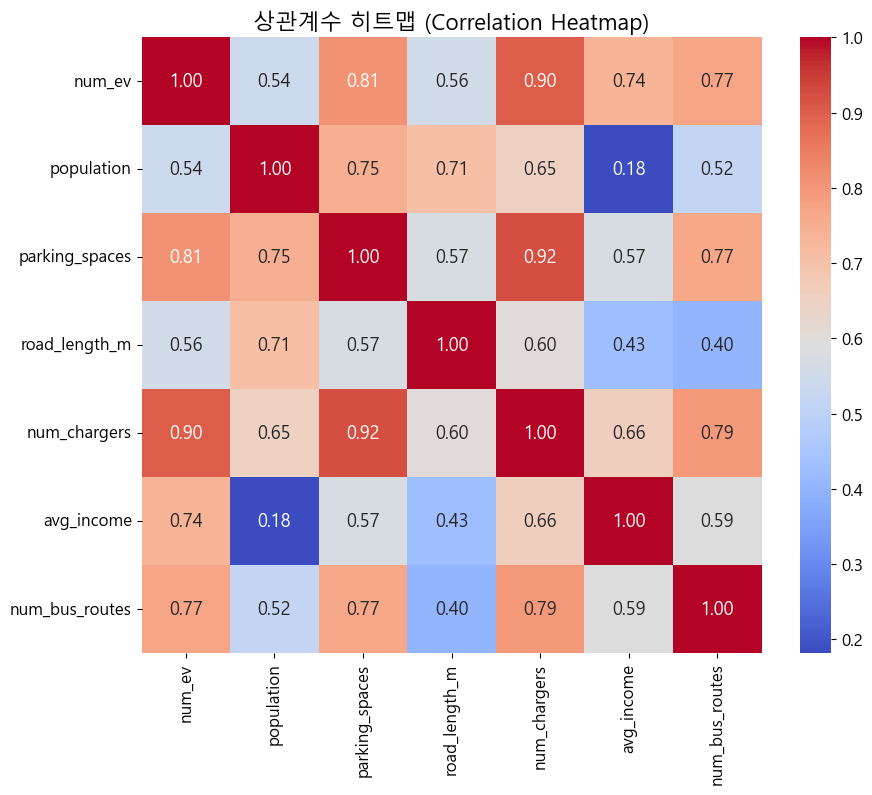

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("상관계수 히트맵 (Correlation Heatmap)")
plt.show()

산점도

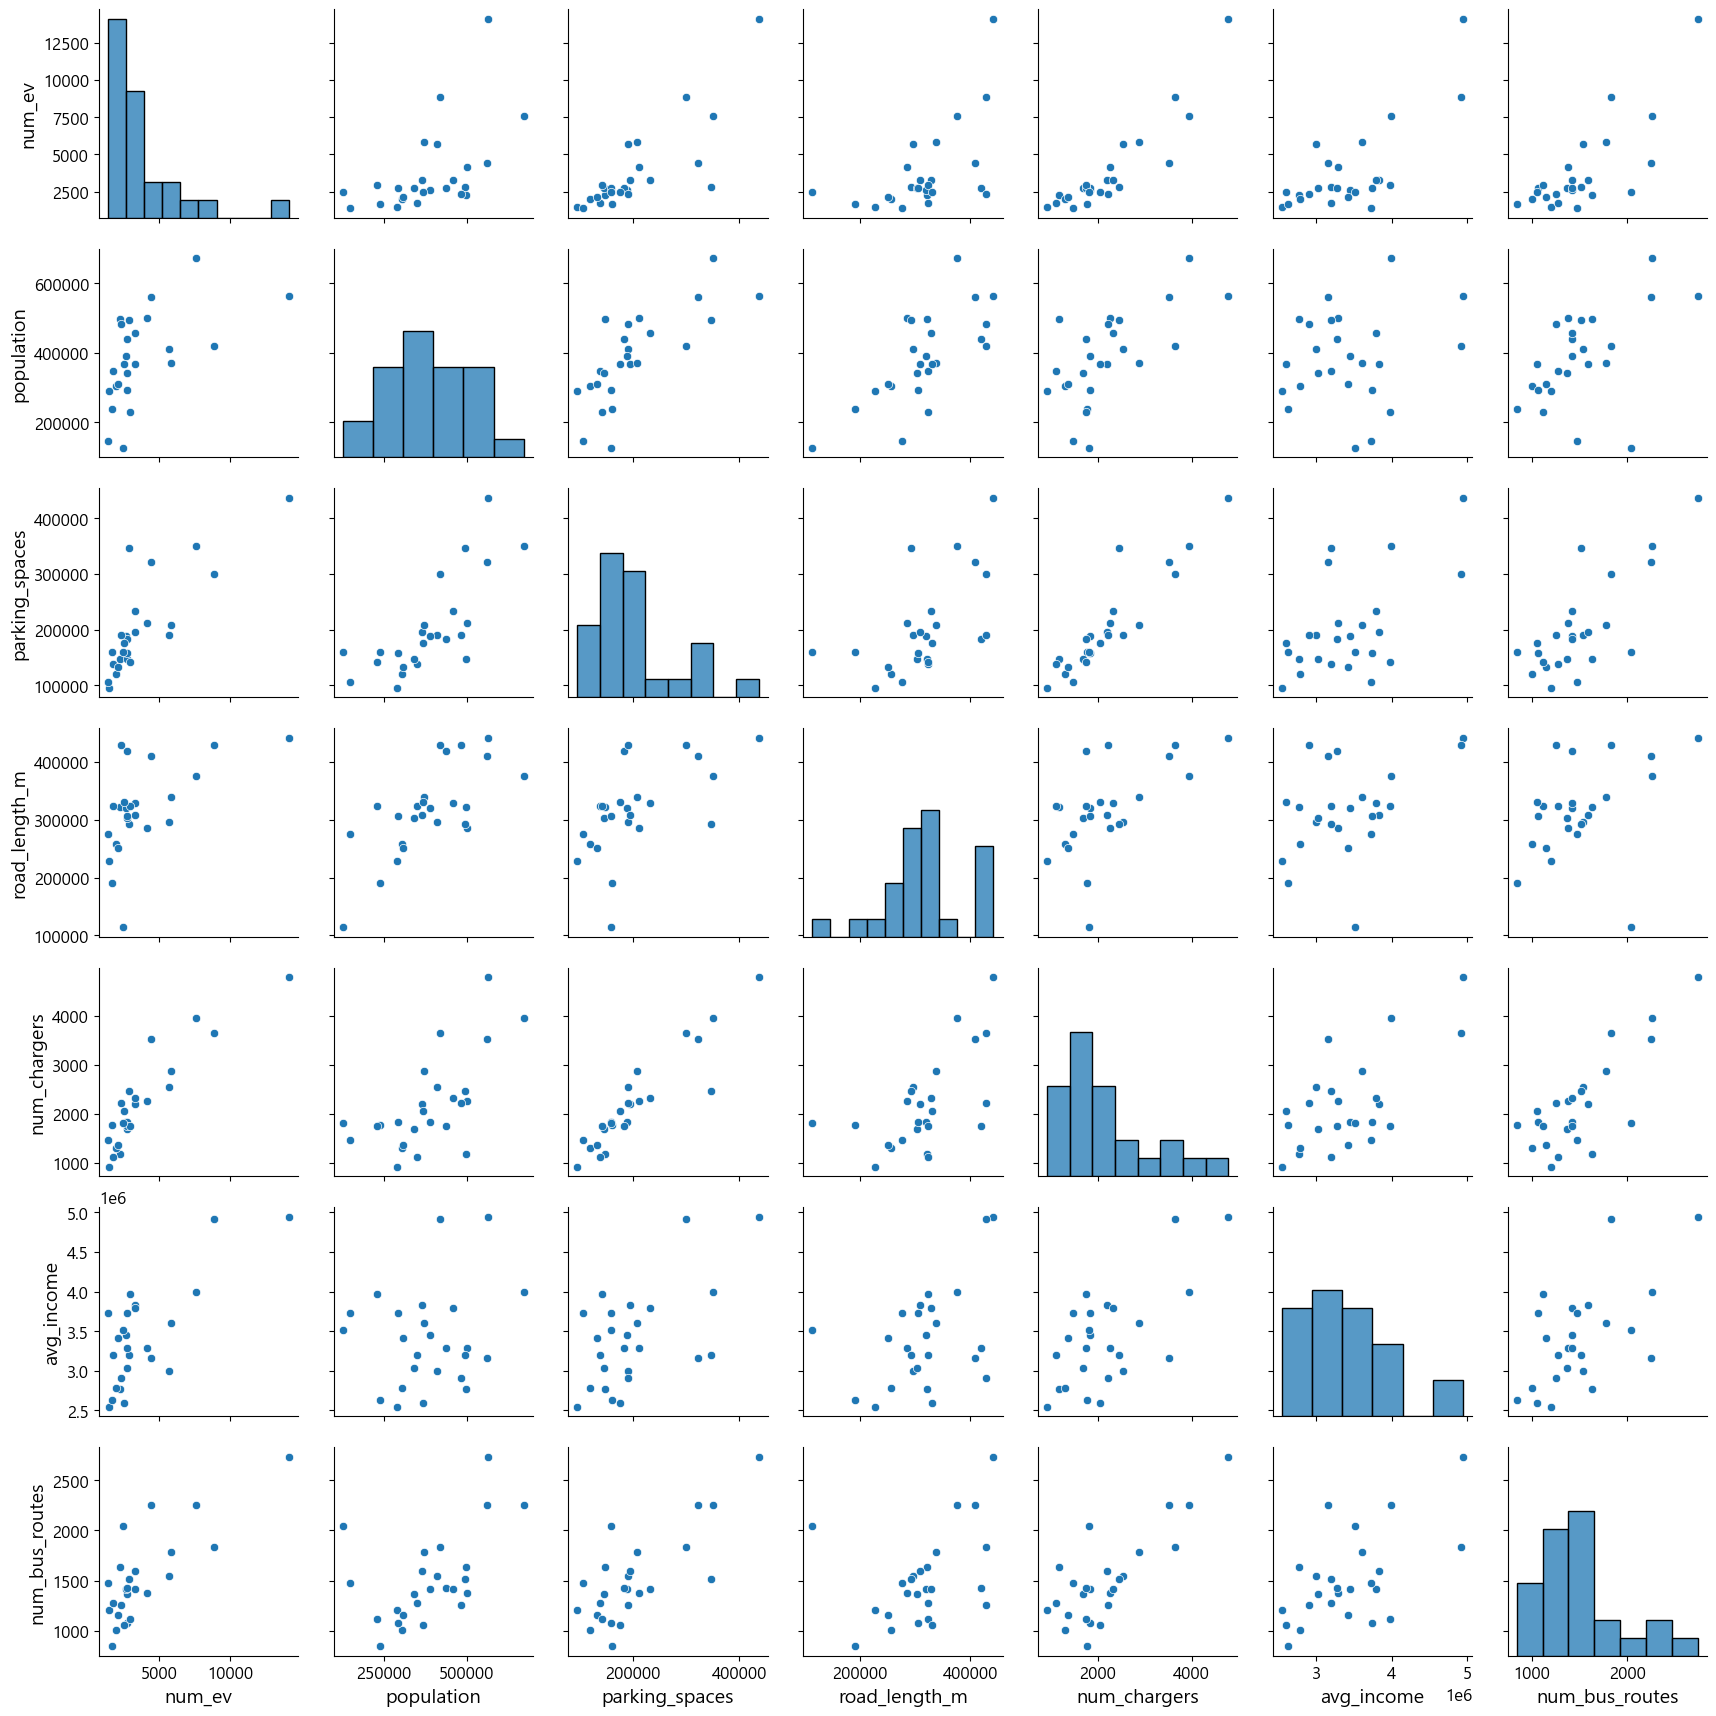

In [53]:
sns.pairplot(df)
plt.show()

# XGBoost

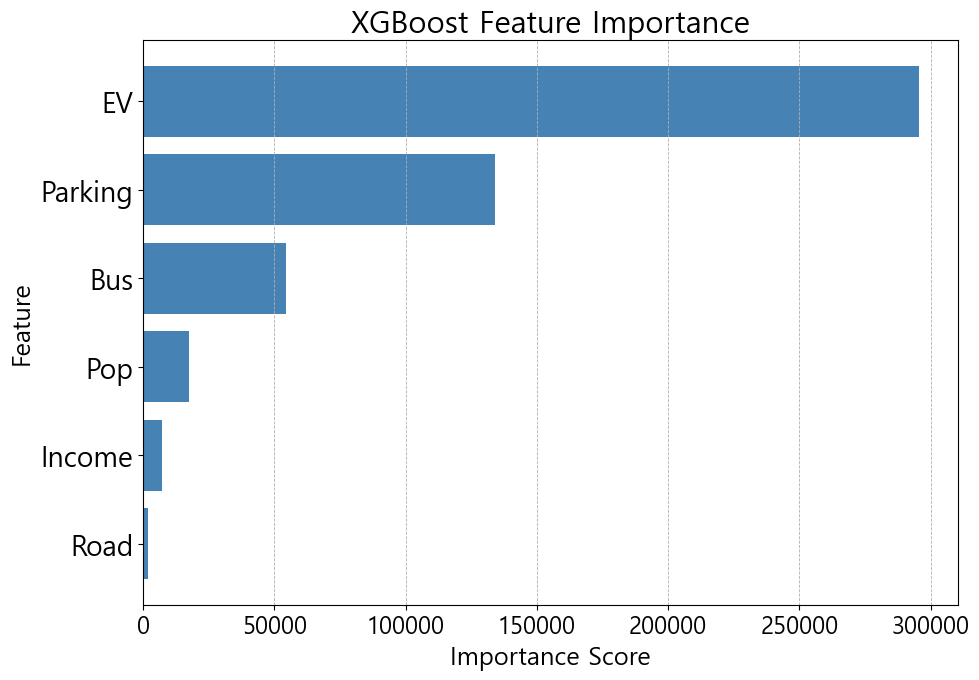

In [58]:
# =========================
# Feature Importance 시각화
# =========================
importance = model.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
})

# f0, f1 ... → 원래 df 컬럼명으로 복원
importance_df['Feature'] = importance_df['Feature'].apply(
    lambda x: X.columns[int(x[1:])] if x.startswith('f') else x
)

# y축에만 사용할 표시용 이름 (그래프용)
feature_label_map = {
    'num_ev': 'EV',
    'parking_spaces': 'Parking',
    'num_bus_routes': 'Bus',
    'population': 'Pop',
    'avg_income': 'Income',
    'road_length_m': 'Road'
}

importance_df['Feature_label'] = importance_df['Feature'].map(feature_label_map)

# 정렬
importance_df = importance_df.sort_values(
    by='Importance', ascending=True
)

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 7))

plt.barh(
    importance_df['Feature_label'],
    importance_df['Importance'],
    color='steelblue'
)

plt.title('XGBoost Feature Importance', fontsize=22)
plt.xlabel('Importance Score', fontsize=18)
plt.ylabel('Feature', fontsize=18)

plt.xticks(fontsize=17)
plt.yticks(fontsize=20)   # 🔥 y축 이름 크게

plt.grid(axis='x', linestyle='--', linewidth=0.6)
plt.tight_layout()
plt.savefig('XGBoost_Feature_Importance_Custom.png', dpi=300)
plt.show()


# 표준화

In [59]:
from sklearn.preprocessing import StandardScaler

# Original X, y
X = df[['num_ev', 'population', 'parking_spaces', 'road_length_m', 'avg_income', 'num_bus_routes']]
y = df['num_chargers']

# Apply standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save standardized X separately
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [34]:
X_scaled_df.head()

,num_ev,population,parking_spaces,road_length_m,avg_income,num_bus_routes
0,3.706053,1.400492,2.800981,1.675819,2.497406,2.826209
1,0.141000,0.904827,0.130289,-0.403258,-0.194176,-0.292452
2,-0.816951,-0.751953,-1.259250,-1.175707,-1.409389,-0.691751
3,0.227892,1.376213,1.437460,1.240489,-0.409756,1.713221
4,-0.536253,0.882949,-0.645967,0.080924,-1.043443,0.297317


In [35]:
from sklearn.model_selection import train_test_split

# 표준화된 데이터 사용
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)


# KNN

In [36]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regressor (n_neighbors=5 사용)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 예측
knn_pred = knn_model.predict(X_test_scaled)

# 성능 평가
mse = mean_squared_error(y_test, knn_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, knn_pred)

print(f'📊 KNN (표준화) MSE: {mse:.2f}')
print(f'📊 KNN (표준화) RMSE: {rmse:.2f}')
print(f'📊 KNN (표준화) R²: {r2:.4f}')

📊 KNN (표준화) MSE: 483933.26
📊 KNN (표준화) RMSE: 695.65
📊 KNN (표준화) R²: 0.6369


# KMeans 클러스터링 (자치구 유형 분석)

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Feature selection
X_cluster = df[['num_ev', 'population', 'parking_spaces', 'road_length_m', 'avg_income', 'num_bus_routes']]

# Standardization
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# K-Means clustering (e.g., 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_cluster_scaled)

# Add cluster results
df['cluster'] = kmeans.labels_

# Check results
print(df[['district', 'cluster']])


           district  cluster
0        Gangnam-gu        1
1       Gangdong-gu        2
2        Gangbuk-gu        0
3        Gangseo-gu        2
4         Gwanak-gu        2
5       Gwangjin-gu        0
6           Guro-gu        2
7      Geumcheon-gu        0
8          Nowon-gu        2
9         Dobong-gu        0
10    Dongdaemun-gu        0
11       Dongjak-gu        2
12          Mapo-gu        2
13     Seodaemun-gu        0
14        Seocho-gu        1
15     Seongdong-gu        0
16      Seongbuk-gu        2
17        Songpa-gu        1
18     Yangcheon-gu        2
19  Yeongdeungpo-gu        2
20       Yongsan-gu        0
21     Eunpyeong-gu        2
22        Jongno-gu        0
23          Jung-gu        0
24      Jungnang-gu        0


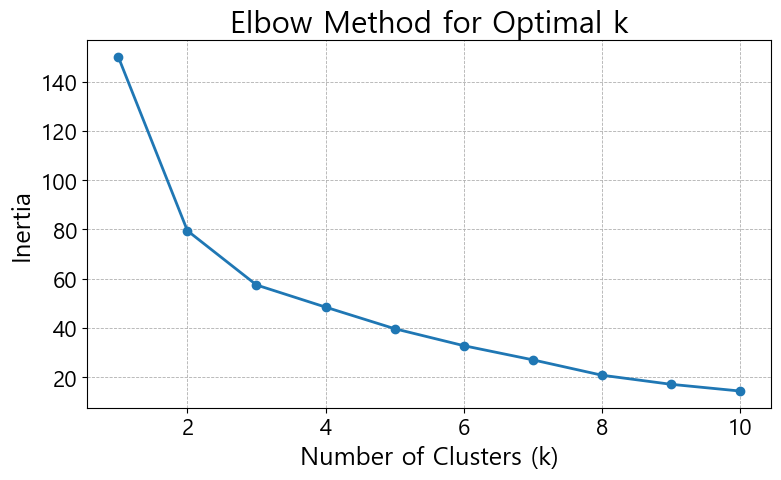

In [62]:
# Elbow point로 클러스터 수 검토

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# =========================
# inertia 기록
# =========================
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


# =========================
# Elbow Method 시각화
# =========================
plt.figure(figsize=(8, 5))   # ⭕ 기존 크기 유지

plt.plot(
    range(1, 11),
    inertia,
    marker='o',
    linewidth=2
)

plt.title('Elbow Method for Optimal k', fontsize=22)   # 🔥 제목 크게
plt.xlabel('Number of Clusters (k)', fontsize=18)      # 🔥 x축 크게
plt.ylabel('Inertia', fontsize=18)                     # 🔥 y축 크게

plt.xticks(fontsize=16)    # 🔥 눈금 글씨 크게
plt.yticks(fontsize=16)

plt.grid(True, linestyle='--', linewidth=0.6)
plt.tight_layout()
plt.show()


## KMeans 해석
# 클러스터 0 (공급 취약형)
주요 자치구: 강북구, 도봉구, 중구, 종로구 등

상대적으로 전기차수와 충전소개수가 모두 낮고, 주차면수 및 도로연장도 제한적인 지역 다수 포함.

중심 업무지구(중구, 종로구) 일부 포함되나 상권 특성상 주거 인프라가 취약하고 충전소 수요가 잠재적으로 억제됨.

정책적으로 기본 인프라 확충 필요성이 높음.

# 클러스터 1 (공급 과밀·집중형)
주요 자치구: 강남구, 서초구, 송파구, 강서구

전기차수와 충전소개수가 모두 높고, 주차면수가 충분함.

고소득권과 상권 밀집지역이 포함되어 설치 여건이 양호하며 과밀 공급 상태 가능성.

수요 예측 정확성과 효율적 자원 배분 필요.

# 클러스터 2 (균형·성장형)
주요 자치구: 강동구, 관악구, 구로구, 노원구, 마포구 등

전기차 보급과 충전소 설치가 비교적 균형적으로 나타남.

인구수와 버스노선수가 상대적으로 높아 교통 접근성이 좋음.

추가 수요 증가에 대응할 단계적 확충 계획 필요




# 의미 및 활용

전기차 인프라 확충 필요 지역 파악:

→ 클러스터 0번 우선 확충 대상

성숙·과밀 지역 관리:

→ 클러스터 1번 적정 수요/공급 관리, 과도한 설치 억제 고려

정책 균형 설계 가능:

→ 클러스터 유형별로 맞춤형 정책 (지원금, 설치 우선순위) 설정 가능

In [39]:
# 클러스터별 평균값 계산
cluster_summary = (
    df.groupby('cluster')[['num_ev', 'num_chargers', 'population', 'parking_spaces', 
                          'road_length_m', 'avg_income', 'num_bus_routes']].mean().round(1)
)

# 출력
cluster_summary


,num_ev,num_chargers,population,parking_spaces,road_length_m,avg_income,num_bus_routes
cluster,,,,,,,
0,2164.9,1550.1,272179.5,139651.3,264051.6,3195457.5,1238.3
1,10194.0,4121.7,551238.0,362555.0,415706.7,4617382.3,2275.0
2,3583.7,2286.4,451699.6,219938.8,341040.4,3299716.4,1565.0


# 클러스터 지도 시각화

In [40]:
import pandas as pd

# 서울시 자치구별 전기차 인프라 데이터 (다시 선언)
import pandas as pd

# 서울시 자치구별 전기차 인프라 + 평균소득 데이터프레임
df = pd.DataFrame({
    '자치구': [
        '강남구', '강동구', '강북구', '강서구', '관악구',
        '광진구', '구로구', '금천구', '노원구', '도봉구',
        '동대문구', '동작구', '마포구', '서대문구', '서초구',
        '성동구', '성북구', '송파구', '양천구', '영등포구',
        '용산구', '은평구', '종로구', '중구', '중랑구'
    ],
    '전기차수': [
        14117, 4147, 1468, 4390, 2253,
        1751, 5690, 1696, 2842, 1991,
        2766, 2639, 3286, 2108, 8874,
        2765, 2736, 7591, 3291, 5819,
        2932, 2328, 1389, 2447, 2501
    ],
    '인구수': [
        563189, 500002, 288797, 560094, 497213,
        348660, 410727, 238431, 495111, 305391,
        342492, 389561, 366111, 309237, 418086,
        291900, 438329, 672439, 458189, 371319,
        228399, 482040, 146790, 125765, 368112
    ],
    '주차면수': [
        436740, 212658, 96070, 322335, 147527,
        138776, 190838, 160301, 347011, 120311,
        146659, 189298, 194947, 132501, 300197,
        158574, 183163, 350728, 232841, 208329,
        142425, 190380, 105896, 159304, 175347
    ],
    '도로연장(m)': [
        441986, 285839, 227825, 409291, 322203,
        322897, 296921, 190888, 292855, 257451,
        303755, 320077, 308580, 250642, 429135,
        305950, 419401, 375999, 329070, 338558,
        323759, 428649, 275701, 114232, 331468
    ],
    '충전소개수': [
        4781, 2266, 915, 3517, 1172,
        1114, 2545, 1772, 2455, 1308,
        1682, 1835, 2195, 1354, 3636,
        1823, 1755, 3948, 2312, 2874,
        1756, 2224, 1465, 1817, 2045
    ],
    '월평균소득': [
        4943841, 3292857, 2547460, 3160623, 2771927,
        3192971, 2994059, 2632285, 3195375, 2785111,
        3030256, 3454170, 3832436, 3417706, 4912401,
        3734499, 3281773, 3995905, 3796034, 3604887,
        3971498, 2912739, 3725859, 3513603, 2598785
    ],
    '버스노선수': [
        2738, 1379, 1205, 2253, 1636,
        1277, 1542, 844, 1518, 1005,
        1370, 1417, 1591, 1152, 1832,
        1072, 1424, 2255, 1417, 1781,
        1121, 1257, 1471, 2044, 1060
    ],
    '클러스터': [
        1, 2, 0, 1, 2,
        0, 2, 0, 2, 0,
        0, 2, 2, 0, 1,
        0, 2, 1, 2, 2,
        0, 2, 0, 0, 2
    ]
})


In [41]:
import geopandas as gpd

# Shapefile 경로
shp_path = "C:/Users/mingm/OneDrive/바탕 화면/강남대/2025 전자공학회_강릉/데이터/지도/LARD_ADM_SECT_SGG_11_202505.shp"

# Shapefile 읽기
gdf = gpd.read_file(shp_path)

# 현재 좌표계 확인
print(gdf.crs)

# WGS84 (EPSG:4326) 로 변환
gdf = gdf.to_crs(epsg=4326)

# GeoJSON 저장
gdf.to_file('seoul_districts_wgs84.geojson', driver='GeoJSON')

PROJCS["KGD2002_Central_Belt_2010 (deprecated)",GEOGCS["KGD2002",DATUM["Korean_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6737"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4737"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102082"]]


In [42]:
# '서울특별시 ' 제거
df['자치구_full'] = '서울특별시 ' + df['자치구']

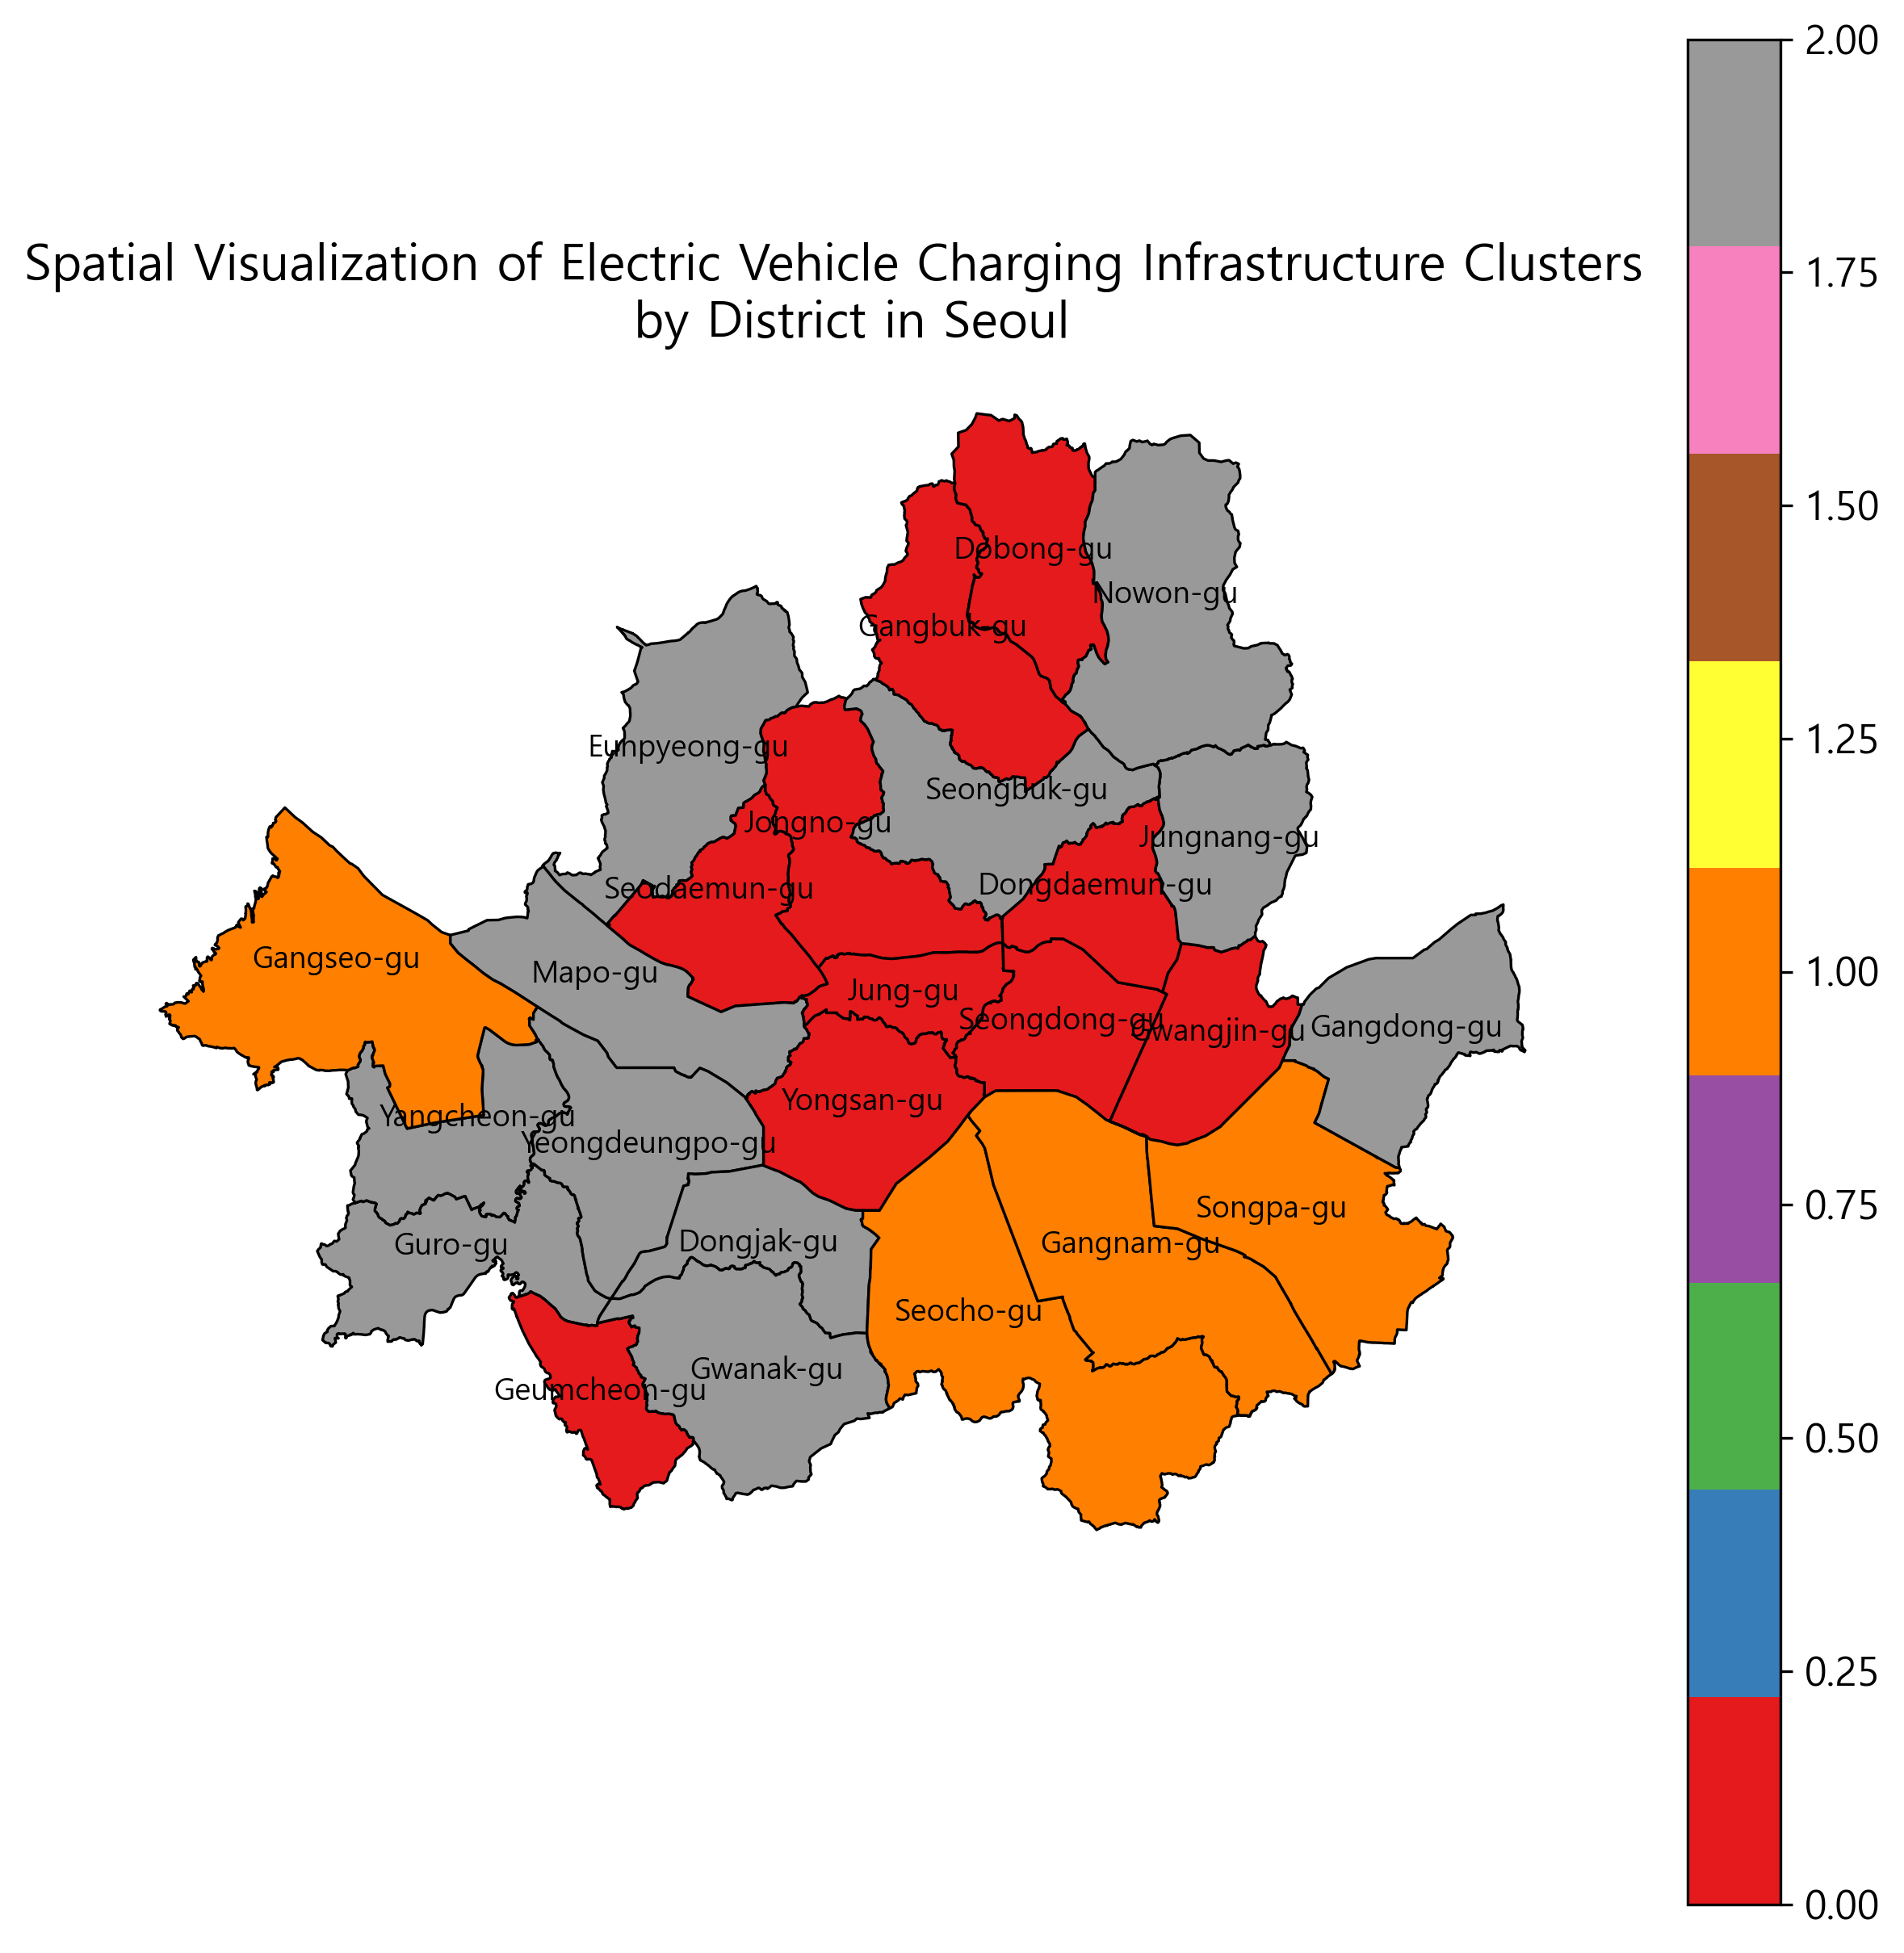

In [43]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1️⃣ SHP 파일 불러오기
shp = gpd.read_file(r"C:\Users\mingm\OneDrive\바탕 화면\강남대\2025 전자공학회_강릉\데이터\지도\LARD_ADM_SECT_SGG_11_202505.shp")

# 2️⃣ 자치구 이름 정리 (서울특별시 제거)
shp['자치구'] = shp['SGG_NM'].str.replace('서울특별시 ', '')
df['자치구'] = df['자치구'].str.replace(' ', '')  # 혹시 공백 제거

# 3️⃣ Merge (클러스터 정보 붙이기)
merged = shp.merge(df[['자치구', '클러스터']], on='자치구')

# 🔥 4️⃣ 한글 폰트 설정 (윈도우 - 맑은 고딕)
font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 5️⃣ 고해상도 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)  # 🔥 논문용 해상도

# 6️⃣ 지도 plot
merged.plot(
    column='클러스터',
    ax=ax,
    legend=True,
    cmap='Set1',   # 🎨 컬러맵 (Set1 추천 or tab10, Pastel1)
    edgecolor='black',
    linewidth=0.8
)

# 🔹 자치구 한→영 매핑 (라벨용)
kr2en = {
    '강남구':'Gangnam-gu','강동구':'Gangdong-gu','강북구':'Gangbuk-gu','강서구':'Gangseo-gu','관악구':'Gwanak-gu',
    '광진구':'Gwangjin-gu','구로구':'Guro-gu','금천구':'Geumcheon-gu','노원구':'Nowon-gu','도봉구':'Dobong-gu',
    '동대문구':'Dongdaemun-gu','동작구':'Dongjak-gu','마포구':'Mapo-gu','서대문구':'Seodaemun-gu','서초구':'Seocho-gu',
    '성동구':'Seongdong-gu','성북구':'Seongbuk-gu','송파구':'Songpa-gu','양천구':'Yangcheon-gu','영등포구':'Yeongdeungpo-gu',
    '용산구':'Yongsan-gu','은평구':'Eunpyeong-gu','종로구':'Jongno-gu','중구':'Jung-gu','중랑구':'Jungnang-gu'
}
merged['label_en'] = merged['자치구'].map(kr2en).fillna(merged['자치구'])

# 🔹 자치구명 표시 (영문)
for _, row in merged.iterrows():
    x, y = row['geometry'].representative_point().coords[0]  # centroid 대신 representative_point()
    plt.annotate(
        text=row['label_en'],
        xy=(x, y),
        horizontalalignment='center',
        fontsize=9
    )


# 8️⃣ 꾸미기
plt.axis('off')
plt.title('Spatial Visualization of Electric Vehicle Charging Infrastructure Clusters \n by District in Seoul', fontsize=15)

# 9️⃣ 저장 (논문/포스터용 파일로)
plt.savefig('서울시_전기차_클러스터_논문용.png', dpi=300, bbox_inches='tight')

# 10️⃣ show
plt.show()

# 정책 우선순위

In [44]:
import pandas as pd

# 서울시 자치구별 전기차 인프라 데이터 (다시 선언)
import pandas as pd

# 서울시 자치구별 전기차 인프라 + 평균소득 데이터프레임
df = pd.DataFrame({
    '자치구': [
        '강남구', '강동구', '강북구', '강서구', '관악구',
        '광진구', '구로구', '금천구', '노원구', '도봉구',
        '동대문구', '동작구', '마포구', '서대문구', '서초구',
        '성동구', '성북구', '송파구', '양천구', '영등포구',
        '용산구', '은평구', '종로구', '중구', '중랑구'
    ],
    '전기차수': [
        14117, 4147, 1468, 4390, 2253,
        1751, 5690, 1696, 2842, 1991,
        2766, 2639, 3286, 2108, 8874,
        2765, 2736, 7591, 3291, 5819,
        2932, 2328, 1389, 2447, 2501
    ],
    '인구수': [
        563189, 500002, 288797, 560094, 497213,
        348660, 410727, 238431, 495111, 305391,
        342492, 389561, 366111, 309237, 418086,
        291900, 438329, 672439, 458189, 371319,
        228399, 482040, 146790, 125765, 368112
    ],
    '주차면수': [
        436740, 212658, 96070, 322335, 147527,
        138776, 190838, 160301, 347011, 120311,
        146659, 189298, 194947, 132501, 300197,
        158574, 183163, 350728, 232841, 208329,
        142425, 190380, 105896, 159304, 175347
    ],
    '도로연장(m)': [
        441986, 285839, 227825, 409291, 322203,
        322897, 296921, 190888, 292855, 257451,
        303755, 320077, 308580, 250642, 429135,
        305950, 419401, 375999, 329070, 338558,
        323759, 428649, 275701, 114232, 331468
    ],
    '충전소개수': [
        4781, 2266, 915, 3517, 1172,
        1114, 2545, 1772, 2455, 1308,
        1682, 1835, 2195, 1354, 3636,
        1823, 1755, 3948, 2312, 2874,
        1756, 2224, 1465, 1817, 2045
    ],
    '월평균소득': [
        4943841, 3292857, 2547460, 3160623, 2771927,
        3192971, 2994059, 2632285, 3195375, 2785111,
        3030256, 3454170, 3832436, 3417706, 4912401,
        3734499, 3281773, 3995905, 3796034, 3604887,
        3971498, 2912739, 3725859, 3513603, 2598785
    ],
    '버스노선수': [
        2738, 1379, 1205, 2253, 1636,
        1277, 1542, 844, 1518, 1005,
        1370, 1417, 1591, 1152, 1832,
        1072, 1424, 2255, 1417, 1781,
        1121, 1257, 1471, 2044, 1060
    ],
    '클러스터': [
        1, 2, 0, 1, 2,
        0, 2, 0, 2, 0,
        0, 2, 2, 0, 1,
        0, 2, 1, 2, 2,
        0, 2, 0, 0, 2
    ]
})


    자치구  충전소개수  OOF_예상_충전소개수       과부족_차이       부족률   전기차수     인구수  \
0   강북구    915   1530.482300   615.482300  0.672658   1468  288797   
1   관악구   1172   1781.959961   609.959961  0.520444   2253  497213   
2   구로구   2545   3267.304688   722.304688  0.283813   5690  410727   
3   강남구   4781   3752.179199 -1028.820801  0.000000  14117  563189   
4   송파구   3948   4166.645996   218.645996  0.055381   7591  672439   
5  영등포구   2874   3254.606934   380.606934  0.132431   5819  371319   
6   성북구   1755   2094.622314   339.622314  0.193517   2736  438329   
7   서초구   3636   3613.020752   -22.979248  0.000000   8874  418086   
8   동작구   1835   2079.969238   244.969238  0.133498   2639  389561   
9   강동구   2266   2375.215332   109.215332  0.048197   4147  500002   

   priority_score  rank  권장_설치대수  
0        1.730074     1      180  
1        1.433630     2      160  
2        0.890271     3       90  
3        0.887924     4        5  
4        0.482130     5       35  
5        0.337351  

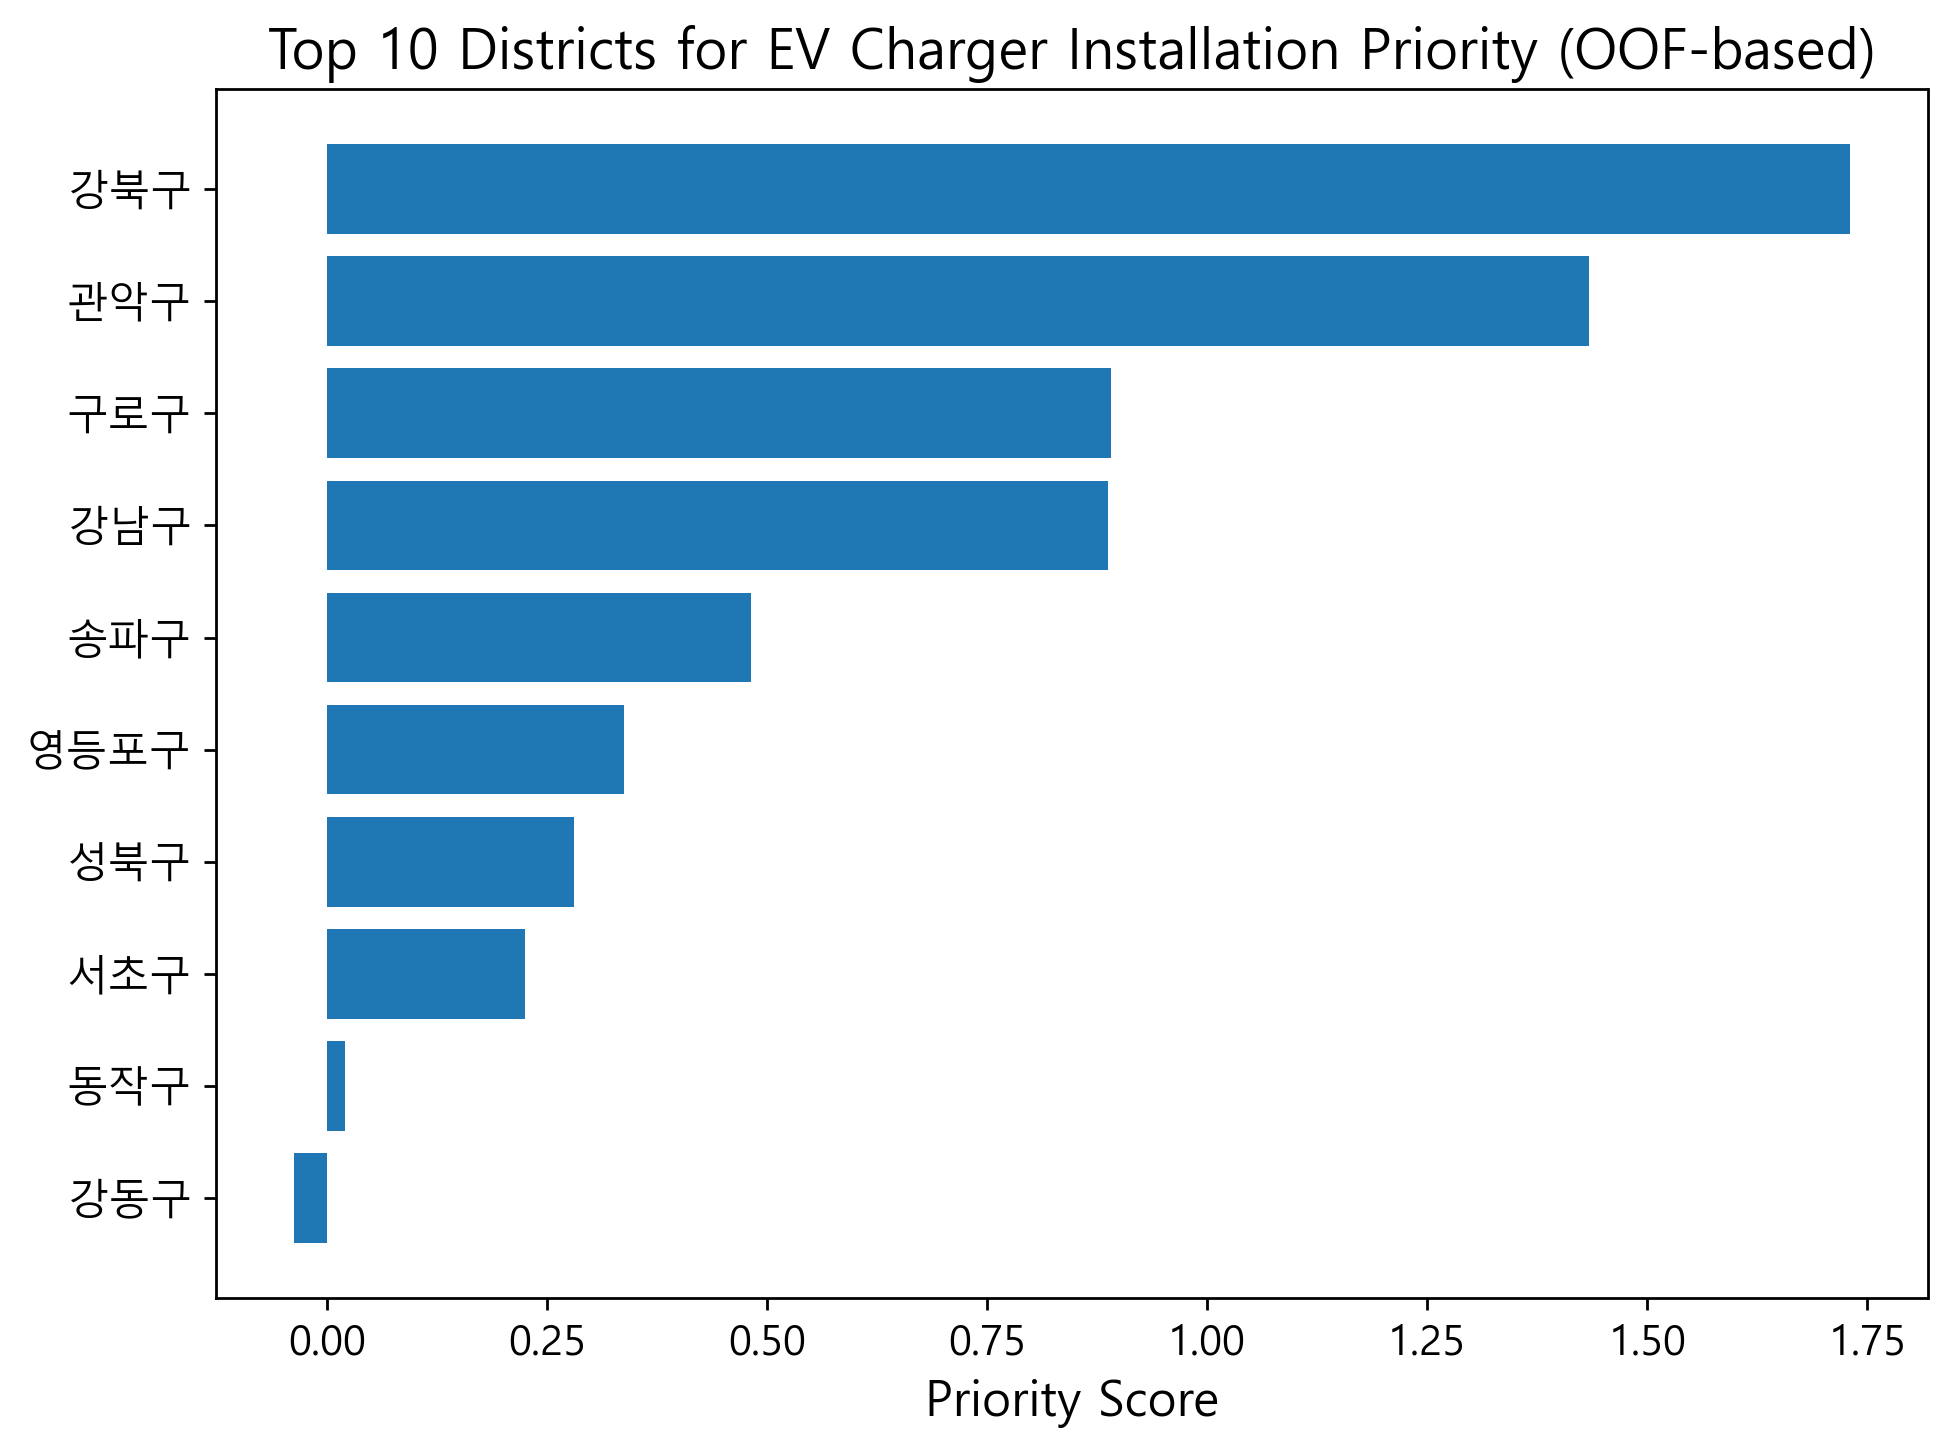

In [45]:
# ===============================================================
# 🔹 OOF 기반 정책 우선순위 + 예산 배분형 권장 설치대수 (논문/실무용)
#      - 입력 df 컬럼: 자치구, 충전소개수, 전기차수, 인구수, 주차면수, 도로연장(m), 월평균소득, 버스노선수
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

# -----------------------------
# 0) 설정
# -----------------------------
FEATURES = ['전기차수','인구수','주차면수','도로연장(m)','월평균소득','버스노선수']
TARGET   = '충전소개수'

N_SPLITS = 5                 # OOF 폴드 수
RANDOM_STATE = 42

ALPHA = 0.30                 # 상위 30%만 배정
TOTAL_BUDGET = 500           # 🔴 총 권장 설치 물량(예: 500기) — 필요 시 조정
MIN_PER_DIST = 5             # 구당 최소 배정 단위(선택)
STEP = 5                     # 5기 단위 반올림

# -----------------------------
# 1) OOF(out-of-fold) 예측
# -----------------------------
X = df[FEATURES].copy()
y = df[TARGET].astype(float).copy()

oof_pred = np.zeros(len(df), dtype=float)

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
for tr_idx, va_idx in kf.split(X):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr = y.iloc[tr_idx]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    oof_pred[va_idx] = model.predict(X_va)

df['OOF_예상_충전소개수'] = oof_pred

# -----------------------------
# 2) 갭/부족률 계산 (OOF 기반)
# -----------------------------
df['과부족_차이'] = df['OOF_예상_충전소개수'] - df['충전소개수']            # (+) 부족, (-) 과잉
denom = df['충전소개수'].replace(0, 1e-9)
df['부족률'] = (df['OOF_예상_충전소개수'] - df['충전소개수']) / denom
df['부족률'] = df['부족률'].clip(lower=0)                                 # 부족만 양수

# -----------------------------
# 3) 우선순위 점수 (z-score 가중합)
# -----------------------------
def zscore(s):
    s = pd.to_numeric(s, errors='coerce').fillna(0)
    sd = s.std()
    return (s - s.mean()) / sd if sd != 0 else s*0

W_NEED, W_EV, W_POP = 0.6, 0.3, 0.1
df['priority_score'] = (
    W_NEED * zscore(df['부족률']) +
    W_EV   * zscore(df['전기차수']) +
    W_POP  * zscore(df['인구수'])
)

df['rank'] = df['priority_score'].rank(ascending=False, method='min').astype(int)
cut = df['priority_score'].quantile(1 - ALPHA)
df['is_top'] = df['priority_score'] >= cut

# -----------------------------
# 4) 예산 배분형 권장 설치대수
#    - 상위 구간들에 priority_weight 비례 배분
# -----------------------------
# 음수 방지 위해 0~1 정규화(상위구만)
top = df[df['is_top']].copy()
eps = 1e-9
top['score01'] = (top['priority_score'] - top['priority_score'].min()) / (top['priority_score'].max() - top['priority_score'].min() + eps)
# 부족률이 0인 곳은 배제(실제 추가 필요 없으므로)
top['weight'] = top['score01'] * (top['부족률'] > 0)

# 가중치 합이 0이면 전부 0
if top['weight'].sum() <= 0:
    df['권장_설치대수'] = 0
else:
    # 초기 연속 배분
    cont_alloc = TOTAL_BUDGET * (top['weight'] / top['weight'].sum())

    # 최소 물량/단위 반올림
    cont_alloc = np.maximum(cont_alloc, MIN_PER_DIST)
    # STEP 단위 올림
    alloc = (np.ceil(cont_alloc / STEP) * STEP).astype(int)

    # 합이 예산을 초과하면 비례 축소
    overflow = alloc.sum() - TOTAL_BUDGET
    if overflow > 0:
        # 초과분을 큰 배정부터 STEP 단위로 줄이기
        order = np.argsort(-alloc.values)
        for idx in order:
            if overflow <= 0: break
            dec = min(alloc.iloc[idx] - MIN_PER_DIST, ((overflow + STEP - 1)//STEP) * STEP)
            dec = (dec // STEP) * STEP
            if dec > 0:
                alloc.iloc[idx] -= dec
                overflow -= dec

    # 최종 배정 입력
    df['권장_설치대수'] = 0
    df.loc[top.index, '권장_설치대수'] = alloc.values

# -----------------------------
# 5) 결과 표/시각화/저장
# -----------------------------
priority_df = (
    df[['자치구','충전소개수','OOF_예상_충전소개수','과부족_차이','부족률',
        '전기차수','인구수','priority_score','rank','권장_설치대수']]
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)
print(priority_df.head(10))

plt.figure(figsize=(8,6), dpi=250)
top10 = priority_df.head(10).sort_values('priority_score')
plt.barh(top10['자치구'], top10['priority_score'])
plt.xlabel('Priority Score')
plt.title('Top 10 Districts for EV Charger Installation Priority (OOF-based)')
plt.tight_layout()
plt.show()

priority_df.to_csv('EV_priority_OOF_budget_alloc.csv', index=False, encoding='utf-8-sig')


정책 우선순위 지도 시각화

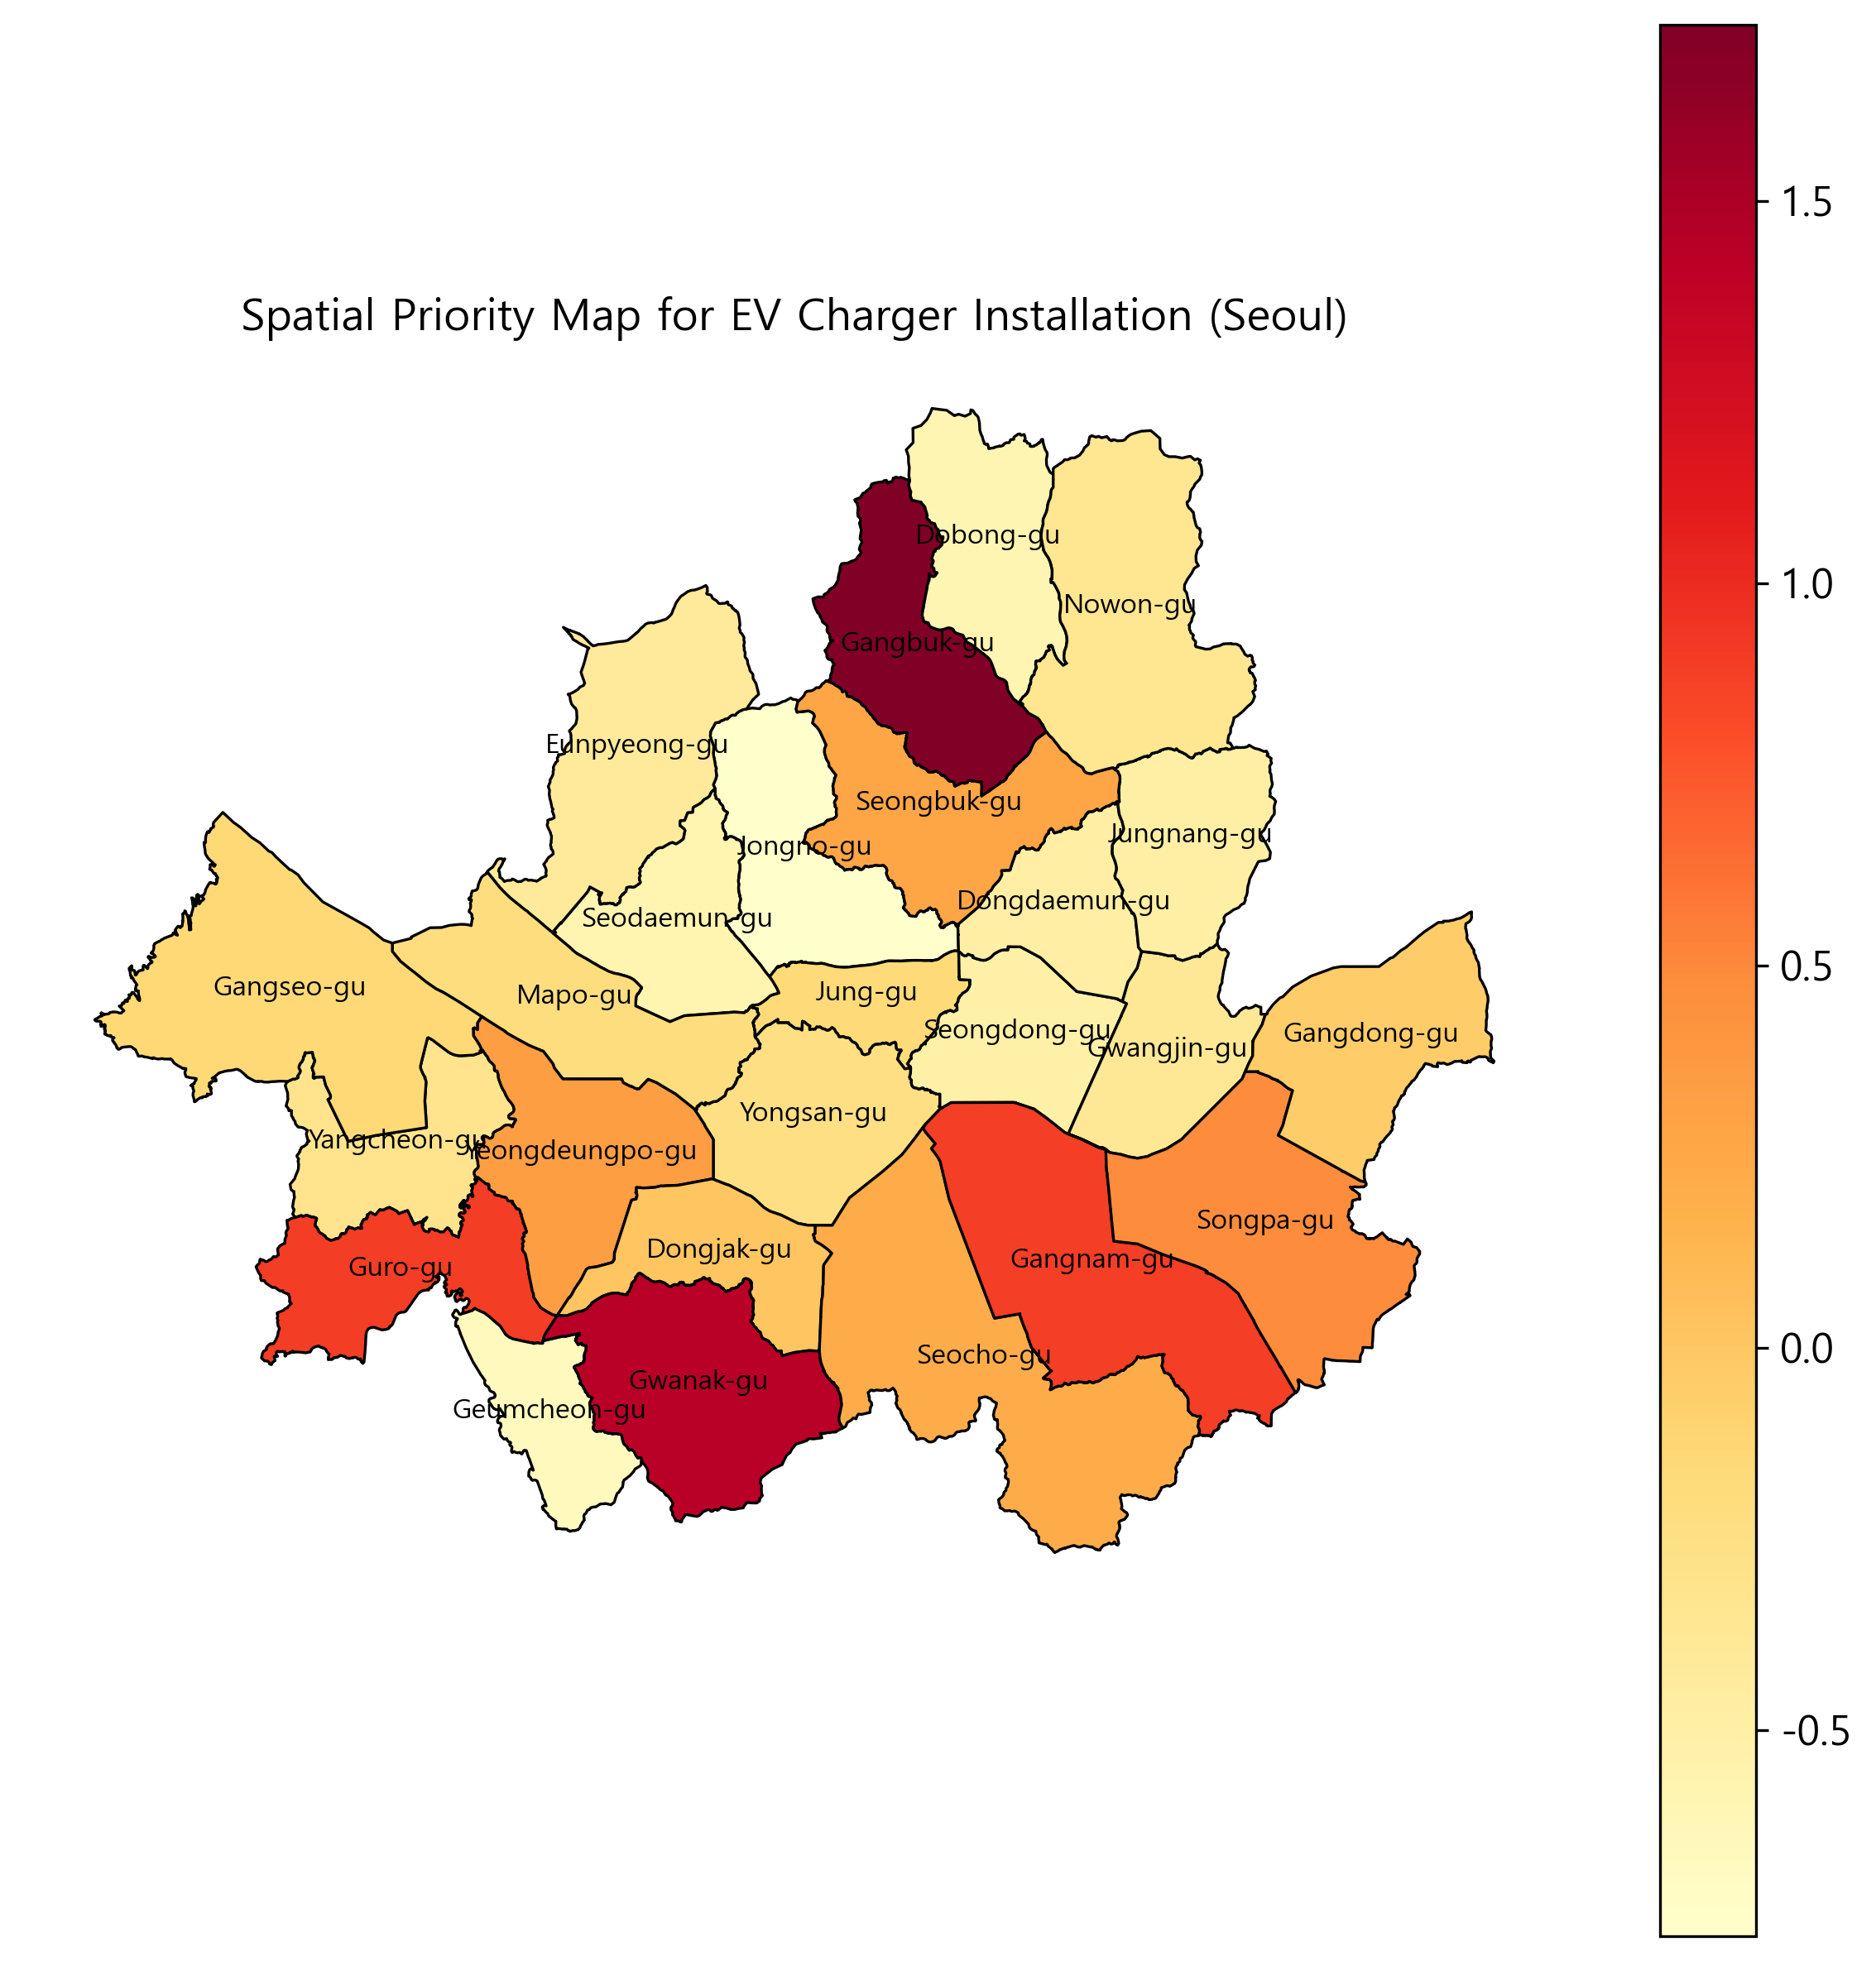

In [46]:
# ===============================================
# 🔹 지도 시각화 (영문 라벨)
# ===============================================
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# (A) 자치구 → 영문 라벨 매핑
district_map = {
    '강남구':'Gangnam-gu','강동구':'Gangdong-gu','강북구':'Gangbuk-gu','강서구':'Gangseo-gu','관악구':'Gwanak-gu',
    '광진구':'Gwangjin-gu','구로구':'Guro-gu','금천구':'Geumcheon-gu','노원구':'Nowon-gu','도봉구':'Dobong-gu',
    '동대문구':'Dongdaemun-gu','동작구':'Dongjak-gu','마포구':'Mapo-gu','서대문구':'Seodaemun-gu','서초구':'Seocho-gu',
    '성동구':'Seongdong-gu','성북구':'Seongbuk-gu','송파구':'Songpa-gu','양천구':'Yangcheon-gu','영등포구':'Yeongdeungpo-gu',
    '용산구':'Yongsan-gu','은평구':'Eunpyeong-gu','종로구':'Jongno-gu','중구':'Jung-gu','중랑구':'Jungnang-gu'
}
df['district'] = df['자치구'].map(district_map)

# (B) SHP 로드 & 병합 (네 경로로 맞춰줘)
shp = gpd.read_file(r"C:\Users\mingm\OneDrive\바탕 화면\강남대\2025 전자공학회_강릉\데이터\지도\LARD_ADM_SECT_SGG_11_202505.shp")
shp['자치구'] = shp['SGG_NM'].str.replace('서울특별시 ', '', regex=False)
merged = shp.merge(df[['자치구','district','priority_score','rank','권장_설치대수']], on='자치구', how='left')

# (C) 폰트 (한글 깨짐 방지; 타이틀만 한글이면 그대로, 아니면 생략 가능)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# (D) 지도: priority_score 컬러링 + 영문 district 라벨
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)
merged.plot(column='priority_score', cmap='YlOrRd', legend=True,
            edgecolor='black', linewidth=0.8, ax=ax)

for _, row in merged.iterrows():
    xy = (row['geometry'].centroid.x, row['geometry'].centroid.y)
    plt.annotate(text=row['district'], xy=xy, ha='center', fontsize=8)

plt.axis('off')
plt.title('Spatial Priority Map for EV Charger Installation (Seoul)', fontsize=13)
plt.savefig('Seoul_EV_Priority_Map_EN.png', dpi=300, bbox_inches='tight')
plt.show()


priority_score = 
    0.6 * z(부족규모) + 
    0.3 * z(전기차수) + 
    0.1 * z(인구수)
